# Rule-Based Baselines

Rule heuristics for fall and return-to-hospital labels using the snapshot dataset.

In [1]:
from __future__ import annotations

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve


In [2]:
def find_repo_root(start: Path) -> Path:
    candidates = [start] + list(start.parents)
    for path in candidates:
        dataset_path = path / "outputs" / "datavision_weekly_2023-08_2025-01.parquet"
        if dataset_path.exists():
            return path
        if (path / "src").exists() and (path / "outputs").exists():
            return path
    raise FileNotFoundError("Could not locate repo root with outputs/datavision_weekly_2023-08_2025-01.parquet")


def find_snapshot_col(df: pd.DataFrame) -> str:
    candidates = [
        "snapshot_date",
        "snapshot_dt",
        "snapshot",
        "reference_date",
        "as_of_date",
        "week_start",
    ]
    for col in candidates:
        if col in df.columns:
            return col
    date_cols = [c for c in df.columns if any(k in c.lower() for k in ["snapshot", "reference", "as_of", "week", "date", "dt", "time"])]
    for col in date_cols:
        if pd.api.types.is_datetime64_any_dtype(df[col]):
            return col
    for col in date_cols:
        parsed = pd.to_datetime(df[col], errors="coerce")
        if parsed.notna().mean() >= 0.9:
            return col
    raise ValueError("No snapshot date column found.")


def ensure_labels(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if "fall_next_30d" not in df.columns and "label_fall_30d" in df.columns:
        df = df.rename(columns={"label_fall_30d": "fall_next_30d"})
    if "rth_next_30d" not in df.columns and "label_rth_30d" in df.columns:
        df = df.rename(columns={"label_rth_30d": "rth_next_30d"})
    missing = [c for c in ["fall_next_30d", "rth_next_30d"] if c not in df.columns]
    if missing:
        raise ValueError(f"Missing label columns: {missing}")
    return df


def temporal_split(df: pd.DataFrame, date_col: str) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df.dropna(subset=[date_col])
    train_end = pd.Timestamp("2024-07-01")
    val_end = pd.Timestamp("2024-11-01")
    train = df[df[date_col] < train_end]
    val = df[(df[date_col] >= train_end) & (df[date_col] < val_end)]
    test = df[df[date_col] >= val_end]
    return train, val, test


def pick_feature(cols: list[str], candidates: list[str]) -> str | None:
    for name in candidates:
        if name in cols:
            return name
    return None


def evaluate_binary(y_true: np.ndarray, y_score: np.ndarray) -> dict:
    y_pred = (y_score >= 0.5).astype(int)
    return {
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, y_score)) if len(np.unique(y_true)) > 1 else None,
        "pr_auc": float(average_precision_score(y_true, y_score)) if len(np.unique(y_true)) > 1 else None,
    }


In [3]:
root = find_repo_root(Path.cwd())
dataset_path = root / "outputs" / "datavision_weekly_2023-08_2025-01.parquet"
df = pd.read_parquet(dataset_path)
df = ensure_labels(df)
date_col = find_snapshot_col(df)
train_df, val_df, test_df = temporal_split(df, date_col)
df.shape, train_df.shape, val_df.shape, test_df.shape

((64089, 204), (34772, 204), (16251, 204), (13066, 204))

In [4]:
cols = df.columns.tolist()

fall_days_col = pick_feature(cols, ["days_since_last_fall", "incidents_days_since_last", "falls_days_since_last"])
fall_count_col = pick_feature(cols, ["falls_count_90d", "incidents_count_90d", "incidents_count_60d"])

rth_days_col = pick_feature(cols, ["days_since_last_admission", "hospital_admissions_days_since_last", "admissions_days_since_last"])
rth_count_col = pick_feature(cols, ["admissions_count_90d", "hospital_admissions_count_90d", "hospital_admissions_count_60d", "admissions_count_60d"])

warnings = []
for name, col in [("fall_days_col", fall_days_col), ("fall_count_col", fall_count_col), ("rth_days_col", rth_days_col), ("rth_count_col", rth_count_col)]:
    if col is None:
        warnings.append(f"Missing expected rule feature: {name}")
warnings

[]

In [5]:
def apply_rule(df: pd.DataFrame, days_col: str | None, count_col: str | None) -> np.ndarray:
    days = df[days_col] if days_col else pd.Series(np.inf, index=df.index)
    count = df[count_col] if count_col else pd.Series(0, index=df.index)
    days = pd.to_numeric(days, errors="coerce").fillna(np.inf)
    count = pd.to_numeric(count, errors="coerce").fillna(0)
    pred = (days <= 30) | (count >= 2)
    return pred.astype(int).values


def evaluate_rule(df: pd.DataFrame, label_col: str, days_col: str | None, count_col: str | None) -> dict:
    y_true = df[label_col].astype(int).values
    y_pred = apply_rule(df, days_col, count_col)
    metrics = evaluate_binary(y_true, y_pred)
    metrics["predicted_positive_rate"] = float(y_pred.mean())
    return metrics


fall_metrics_val = evaluate_rule(val_df, "fall_next_30d", fall_days_col, fall_count_col)
fall_metrics_test = evaluate_rule(test_df, "fall_next_30d", fall_days_col, fall_count_col)
rth_metrics_val = evaluate_rule(val_df, "rth_next_30d", rth_days_col, rth_count_col)
rth_metrics_test = evaluate_rule(test_df, "rth_next_30d", rth_days_col, rth_count_col)
fall_metrics_val, fall_metrics_test, rth_metrics_val, rth_metrics_test

({'precision': 0.28088304368248,
  'recall': 0.4486121530382596,
  'f1': 0.3454650491045638,
  'roc_auc': 0.6729922274777034,
  'pr_auc': 0.17123553294843102,
  'predicted_positive_rate': 0.1310073226262999},
 {'precision': 0.2643348623853211,
  'recall': 0.4742798353909465,
  'f1': 0.3394698085419735,
  'roc_auc': 0.6840970865395282,
  'pr_auc': 0.16447783324153642,
  'predicted_positive_rate': 0.1334761977651921},
 {'precision': 0.07692307692307693,
  'recall': 0.30184804928131415,
  'f1': 0.12260216847372811,
  'roc_auc': 0.594973758210817,
  'pr_auc': 0.04414087014229012,
  'predicted_positive_rate': 0.11759276352224478},
 {'precision': 0.09210526315789473,
  'recall': 0.4057971014492754,
  'f1': 0.15013404825737264,
  'roc_auc': 0.6486575319368065,
  'pr_auc': 0.053065624816471854,
  'predicted_positive_rate': 0.1163324659421399})

In [6]:
from datetime import datetime

reports_dir = root / "reports"
plots_dir = reports_dir / "plots"
models_dir = root / "models"
reports_dir.mkdir(exist_ok=True)
plots_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(exist_ok=True)

run_id = datetime.utcnow().strftime("%Y%m%dT%H%M%SZ")
metrics_rows = [
    {"run_id": run_id, "model": "rule", "target": "fall_next_30d", "split": "val", **fall_metrics_val},
    {"run_id": run_id, "model": "rule", "target": "fall_next_30d", "split": "test", **fall_metrics_test},
    {"run_id": run_id, "model": "rule", "target": "rth_next_30d", "split": "val", **rth_metrics_val},
    {"run_id": run_id, "model": "rule", "target": "rth_next_30d", "split": "test", **rth_metrics_test},
]
metrics_df = pd.DataFrame(metrics_rows)
metrics_path = reports_dir / "model_metrics.csv"
if metrics_path.exists():
    existing = pd.read_csv(metrics_path)
    metrics_df = pd.concat([existing, metrics_df], ignore_index=True)
metrics_df.to_csv(metrics_path, index=False)

rule_config = {
    "fall_rule": {"days_col": fall_days_col, "count_col": fall_count_col, "days_threshold": 30, "count_threshold": 2},
    "rth_rule": {"days_col": rth_days_col, "count_col": rth_count_col, "days_threshold": 30, "count_threshold": 2},
}
with open(models_dir / "fall_rule_model.json", "w", encoding="utf-8") as f:
    json.dump(rule_config["fall_rule"], f, indent=2)
with open(models_dir / "rth_rule_model.json", "w", encoding="utf-8") as f:
    json.dump(rule_config["rth_rule"], f, indent=2)

metrics_df.tail(6)

,run_id,model,target,split,precision,recall,f1,roc_auc,pr_auc,predicted_positive_rate,recall_at_10pct,precision_at_10pct,threshold
36,20260309T003034Z,lightgbm,rth_next_30d,val,0.114462,0.381930,0.176136,0.772865,0.180667,0.099994,0.381930,0.114462,0.080481
37,20260309T003034Z,lightgbm,rth_next_30d,test,0.097169,0.368116,0.153753,0.770839,0.162877,0.100031,0.368116,0.097243,0.080481
38,20260309T004240Z,rule,fall_next_30d,val,0.280883,0.448612,0.345465,0.672992,0.171236,0.131007,NaN,NaN,NaN
39,20260309T004240Z,rule,fall_next_30d,test,0.264335,0.474280,0.339470,0.684097,0.164478,0.133476,NaN,NaN,NaN
40,20260309T004240Z,rule,rth_next_30d,val,0.076923,0.301848,0.122602,0.594974,0.044141,0.117593,NaN,NaN,NaN
41,20260309T004240Z,rule,rth_next_30d,test,0.092105,0.405797,0.150134,0.648658,0.053066,0.116332,NaN,NaN,NaN


Recent-fall tiebreaker column: days_since_last_fall
Age tiebreaker column: age


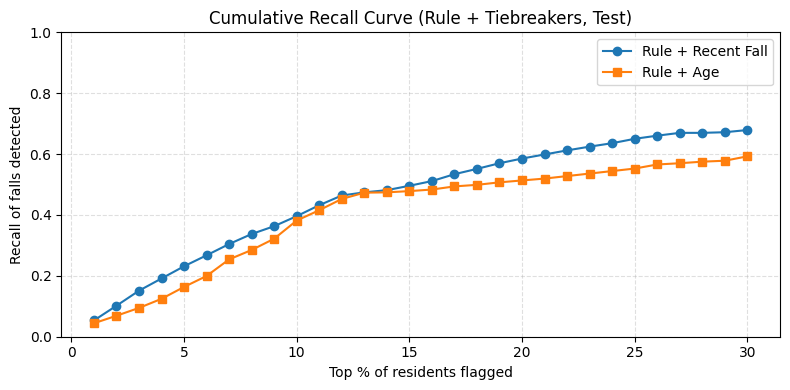

In [ ]:
age_col = pick_feature(cols, ["age", "resident_age", "age_years", "person_age", "patient_age"])
if age_col is None:
    age_candidates = [c for c in cols if "age" in c.lower()]
    age_col = age_candidates[0] if age_candidates else None
if age_col is None:
    raise ValueError("No age column found for tiebreaker.")
if fall_days_col is None:
    raise ValueError("No recent-fall column found for tiebreaker.")

def build_rule_score(
    df: pd.DataFrame,
    label_col: str,
    days_col: str | None,
    count_col: str | None,
    recency_col: str,
) -> tuple[np.ndarray, np.ndarray]:
    y_true = df[label_col].astype(int).values
    rule_pred = apply_rule(df, days_col, count_col).astype(float)
    recency = pd.to_numeric(df[recency_col], errors="coerce")
    recency = recency.fillna(recency.max())
    if recency.max() > recency.min():
        recency_scaled = (recency.max() - recency) / (recency.max() - recency.min())
    else:
        recency_scaled = 0.0
    score = rule_pred + (recency_scaled / 1000.0)
    return y_true, score

def build_age_score(
    df: pd.DataFrame,
    label_col: str,
    days_col: str | None,
    count_col: str | None,
    age_col: str,
) -> tuple[np.ndarray, np.ndarray]:
    y_true = df[label_col].astype(int).values
    rule_pred = apply_rule(df, days_col, count_col).astype(float)
    age = pd.to_numeric(df[age_col], errors="coerce")
    age = age.fillna(age.median())
    if age.max() > age.min():
        age_scaled = (age - age.min()) / (age.max() - age.min())
    else:
        age_scaled = 0.0
    score = rule_pred + (age_scaled / 1000.0)
    return y_true, score

def recall_curve(y_true: np.ndarray, y_score: np.ndarray, max_pct: int = 30) -> tuple[np.ndarray, np.ndarray]:
    order = np.argsort(-y_score)
    y_sorted = y_true[order]
    total_pos = max(1.0, float(y_sorted.sum()))
    recalls = []
    percents = np.arange(1, max_pct + 1)
    for pct in percents:
        n_top = max(1, int(len(y_sorted) * (pct / 100.0)))
        recalls.append(float(y_sorted[:n_top].sum()) / total_pos)
    return percents, np.array(recalls)

y_true_fall, y_score_recent = build_rule_score(
    test_df, "fall_next_30d", fall_days_col, fall_count_col, fall_days_col
)
_, y_score_age = build_age_score(
    test_df, "fall_next_30d", fall_days_col, fall_count_col, age_col
)
percents, recalls_recent = recall_curve(y_true_fall, y_score_recent, max_pct=30)
_, recalls_age = recall_curve(y_true_fall, y_score_age, max_pct=30)
random_recall = percents / 100.0

print(f"Recent-fall tiebreaker column: {fall_days_col}")
print(f"Age tiebreaker column: {age_col}")
plt.figure(figsize=(8, 4))
plt.plot(percents, recalls_recent, marker="o", linewidth=1.5, label="Rule + Recent Fall")
plt.plot(percents, recalls_age, marker="s", linewidth=1.5, label="Rule + Age")
plt.plot(percents, random_recall, linestyle="--", color="gray", linewidth=1.2, label="Random")
plt.xlabel("Top % of residents flagged")
plt.ylabel("Recall of falls detected")
plt.title("Cumulative Recall Curve (Rule + Tiebreakers, Test)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.ylim(0, 1.0)
plt.legend()
plt.tight_layout()
plt.show()

RTH recent-event column: hospital_admissions_days_since_last


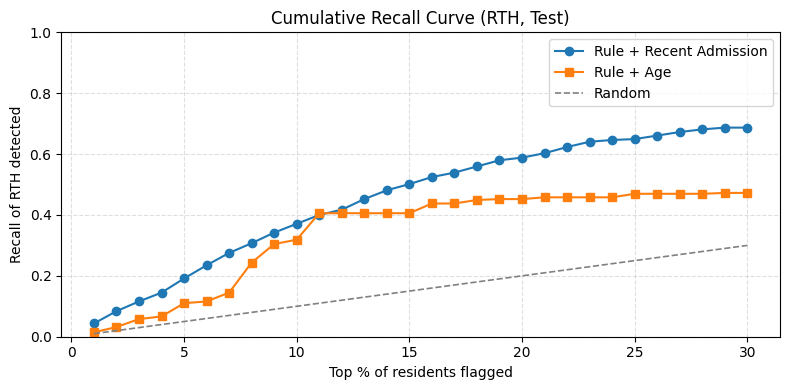

In [10]:
if rth_days_col is None:
    raise ValueError("No recent-admission column found for RTH tiebreaker.")

y_true_rth, y_score_recent_rth = build_rule_score(
    test_df, "rth_next_30d", rth_days_col, rth_count_col, rth_days_col
)
_, y_score_age_rth = build_age_score(
    test_df, "rth_next_30d", rth_days_col, rth_count_col, age_col
)
percents_rth, recalls_recent_rth = recall_curve(y_true_rth, y_score_recent_rth, max_pct=30)
_, recalls_age_rth = recall_curve(y_true_rth, y_score_age_rth, max_pct=30)
random_recall_rth = percents_rth / 100.0

print(f"RTH recent-event column: {rth_days_col}")
plt.figure(figsize=(8, 4))
plt.plot(percents_rth, recalls_recent_rth, marker="o", linewidth=1.5, label="Rule + Recent Admission")
plt.plot(percents_rth, recalls_age_rth, marker="s", linewidth=1.5, label="Rule + Age")
plt.plot(percents_rth, random_recall_rth, linestyle="--", color="gray", linewidth=1.2, label="Random")
plt.xlabel("Top % of residents flagged")
plt.ylabel("Recall of RTH detected")
plt.title("Cumulative Recall Curve (RTH, Test)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.ylim(0, 1.0)
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
export_rows = []
for pct, rec in zip(percents, recalls_recent):
    export_rows.append({"target": "fall_next_30d", "tiebreaker": "recent_fall", "percent_flagged": int(pct), "recall": float(rec)})
for pct, rec in zip(percents, recalls_age):
    export_rows.append({"target": "fall_next_30d", "tiebreaker": "age", "percent_flagged": int(pct), "recall": float(rec)})
for pct, rec in zip(percents_rth, recalls_recent_rth):
    export_rows.append({"target": "rth_next_30d", "tiebreaker": "recent_admission", "percent_flagged": int(pct), "recall": float(rec)})
for pct, rec in zip(percents_rth, recalls_age_rth):
    export_rows.append({"target": "rth_next_30d", "tiebreaker": "age", "percent_flagged": int(pct), "recall": float(rec)})

export_df = pd.DataFrame(export_rows)
export_path = reports_dir / "rule_cumulative_recall_points.csv"
export_df.to_csv(export_path, index=False)
export_path, export_df.head(8)

(PosixPath('/Users/marcelo.florencio/workspace/personal/tricura-incident-risk/reports/rule_cumulative_recall_points.csv'),
           target   tiebreaker  percent_flagged    recall
 0  fall_next_30d  recent_fall                1  0.053498
 1  fall_next_30d  recent_fall                2  0.101852
 2  fall_next_30d  recent_fall                3  0.151235
 3  fall_next_30d  recent_fall                4  0.191358
 4  fall_next_30d  recent_fall                5  0.231481
 5  fall_next_30d  recent_fall                6  0.267490
 6  fall_next_30d  recent_fall                7  0.304527
 7  fall_next_30d  recent_fall                8  0.337449)